# 🌤️ Swiss Weather & Air Quality Analyzer
### Scientific Programming – Final Project | FS2026

**Research Question:**  
*Is there a statistically significant correlation between temperature and air quality (PM2.5) in Swiss cities?*

**Data Sources:**
- 🌡️ [Open-Meteo Archive API](https://open-meteo.com) – daily weather (free, no key required)
- 🌫️ [Open-Meteo Air Quality API](https://open-meteo.com) – hourly PM2.5 / AQI (free, no key required)

**Analysis Period:** January 1 – December 31, 2024  
**Cities:** Zürich, Bern, Geneva, Basel, Lausanne, St. Gallen, Lucerne


In [1]:
# ── 1. IMPORTS ──────────────────────────────────────────────────────────────
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sqlite3
import re
import json
import os
from datetime import datetime
from scipy import stats
import folium
from IPython.display import display, IFrame
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


In [2]:
import sys
!{sys.executable} -m pip install requests pandas numpy matplotlib seaborn scipy folium anthropic

## 1. Data Collection
### 1.1 City Definitions (Tuples, Lists, Dicts, Sets)

In [3]:
# ── 2. CITY DEFINITIONS  ────────────────────────────────────────────────────
# Dict mapping city name → coordinate TUPLE (lat, lon)  [immutable coordinates]
CITY_COORDS = {
    "Zürich":     (47.3769,  8.5417),
    "Bern":       (46.9480,  7.4474),
    "Geneva":     (46.2044,  6.1432),
    "Basel":      (47.5596,  7.5886),
    "Lausanne":   (46.5197,  6.6323),
    "St. Gallen": (47.4245,  9.3767),
    "Lucerne":    (47.0502,  8.3093),
}

# List of city names (ordered, mutable)
city_names = list(CITY_COORDS.keys())

# Sets for regional grouping
western_cities  = {"Geneva", "Lausanne"}
eastern_cities  = {"St. Gallen", "Zürich"}
central_cities  = {"Bern", "Lucerne", "Basel"}
all_regions     = western_cities | eastern_cities | central_cities   # set union

# Analysis period (tuple: immutable start/end)
DATE_RANGE = ("2024-01-01", "2024-12-31")
START_DATE, END_DATE = DATE_RANGE

print(f"Cities to analyze ({len(city_names)}): {city_names}")
print(f"Western cities  : {western_cities}")
print(f"Eastern cities  : {eastern_cities}")
print(f"Central cities  : {central_cities}")
print(f"Analysis period : {START_DATE} → {END_DATE}")


Cities to analyze (7): ['Zürich', 'Bern', 'Geneva', 'Basel', 'Lausanne', 'St. Gallen', 'Lucerne']
Western cities  : {'Lausanne', 'Geneva'}
Eastern cities  : {'Zürich', 'St. Gallen'}
Central cities  : {'Basel', 'Bern', 'Lucerne'}
Analysis period : 2024-01-01 → 2024-12-31


### 1.2 WeatherAnalyzer Class (Object-Oriented Programming)

In [4]:
# ── 3. WEATHERANALYZER CLASS (OOP) ──────────────────────────────────────────
class WeatherAnalyzer:
    """
    Fetches, stores and analyses weather + air quality data
    for Swiss cities using the free Open-Meteo API.
    """

    WEATHER_URL     = "https://archive-api.open-meteo.com/v1/archive"
    AIR_QUALITY_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

    def __init__(self, cities: dict, start_date: str, end_date: str):
        self.cities     = cities          # dict {name: (lat, lon)}
        self.start_date = start_date
        self.end_date   = end_date
        self.df         = None            # will hold the combined DataFrame

    # ── private helpers ──────────────────────────────────────────────────────
    def _fetch_weather(self, city: str) -> dict:
        """Fetch daily weather data for one city."""
        lat, lon = self.cities[city]
        params = {
            "latitude":   lat,
            "longitude":  lon,
            "start_date": self.start_date,
            "end_date":   self.end_date,
            "daily":      ("temperature_2m_mean,temperature_2m_max,"
                           "temperature_2m_min,precipitation_sum,"
                           "windspeed_10m_max"),
            "timezone":   "Europe/Zurich",
        }
        r = requests.get(self.WEATHER_URL, params=params, timeout=30)
        r.raise_for_status()
        return r.json()

    def _fetch_air_quality(self, city: str) -> pd.DataFrame:
        """Fetch hourly air quality, return as daily-averaged DataFrame."""
        lat, lon = self.cities[city]
        params = {
            "latitude":   lat,
            "longitude":  lon,
            "start_date": self.start_date,
            "end_date":   self.end_date,
            "hourly":     "pm2_5,european_aqi",
            "timezone":   "Europe/Zurich",
        }
        r = requests.get(self.AIR_QUALITY_URL, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()["hourly"]
        aq = pd.DataFrame({
            "datetime": pd.to_datetime(data["time"]),
            "pm2_5":    data["pm2_5"],
            "aqi":      data["european_aqi"],
        })
        aq["date"] = aq["datetime"].dt.date.astype(str)
        return aq.groupby("date")[["pm2_5", "aqi"]].mean()

    # ── public method ────────────────────────────────────────────────────────
    def collect_all_data(self) -> pd.DataFrame:
        """Fetch data for ALL cities, combine into a single DataFrame."""
        records = []

        for city in self.cities:
            print(f"  Fetching {city} ...", end=" ", flush=True)
            try:
                # Weather
                w     = self._fetch_weather(city)
                daily = w["daily"]
                dates = daily["time"]

                # Air quality (daily means)
                aq_daily = self._fetch_air_quality(city)

                # Merge row by row
                for i, date in enumerate(dates):
                    row = aq_daily.loc[date] if date in aq_daily.index else pd.Series({"pm2_5": None, "aqi": None})
                    records.append({
                        "city":        city,
                        "date":        date,
                        "lat":         self.cities[city][0],
                        "lon":         self.cities[city][1],
                        "temp_mean":   daily["temperature_2m_mean"][i],
                        "temp_max":    daily["temperature_2m_max"][i],
                        "temp_min":    daily["temperature_2m_min"][i],
                        "precip_mm":   daily["precipitation_sum"][i],
                        "wind_kmh":    daily["windspeed_10m_max"][i],
                        "pm2_5":       row["pm2_5"],
                        "aqi":         row["aqi"],
                    })
                print("✓")
            except Exception as exc:
                print(f"✗  ({exc})")

        self.df = pd.DataFrame(records)
        self.df["date"] = pd.to_datetime(self.df["date"])
        print(f"\nDone – {len(self.df):,} daily records collected.")
        return self.df

print("WeatherAnalyzer class defined ✓")


WeatherAnalyzer class defined ✓


In [5]:
# ── 4. COLLECT DATA ─────────────────────────────────────────────────────────
analyzer = WeatherAnalyzer(CITY_COORDS, START_DATE, END_DATE)
raw_df   = analyzer.collect_all_data()
display(raw_df.head())


  Fetching Zürich ... ✓
  Fetching Bern ... ✓
  Fetching Geneva ... ✓
  Fetching Basel ... ✓
  Fetching Lausanne ... ✓
  Fetching St. Gallen ... ✓
  Fetching Lucerne ... ✓

Done – 2,562 daily records collected.


,city,date,lat,lon,temp_mean,temp_max,temp_min,precip_mm,wind_kmh,pm2_5,aqi
0,Zürich,2024-01-01,47.3769,8.5417,4.0,7.5,0.7,0.4,18.2,3.300000,22.666667
1,Zürich,2024-01-02,47.3769,8.5417,4.3,7.6,-0.1,5.1,18.3,3.591667,21.583333
2,Zürich,2024-01-03,47.3769,8.5417,9.6,12.1,7.7,3.2,32.0,1.704167,28.666667
3,Zürich,2024-01-04,47.3769,8.5417,6.1,8.8,1.1,3.6,27.1,3.008333,25.875000
4,Zürich,2024-01-05,47.3769,8.5417,3.9,6.5,1.1,2.2,6.1,7.641667,16.208333


## 2. Data Preparation
### 2.1 Cleaning & Feature Engineering (incl. Regular Expressions)

In [6]:
# ── 5. DATA PREPARATION ─────────────────────────────────────────────────────
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean the raw DataFrame:
      - Use regex to extract year / month / day from date strings.
      - Derive a 'season' column with conditional statements.
      - Flag high-pollution days (PM2.5 > WHO guideline 15 µg/m³).
      - Drop rows where key measurements are missing.
    """
    df = df.copy()

    # ── Regex: extract date components from ISO date string ──────────────────
    date_pattern = re.compile(r"(\d{4})-(\d{2})-(\d{2})")
    years, months, days = [], [], []

    for val in df["date"].astype(str):
        m = date_pattern.search(val)
        if m:
            years.append(int(m.group(1)))
            months.append(int(m.group(2)))
            days.append(int(m.group(3)))
        else:
            years.append(None); months.append(None); days.append(None)

    df["year"]  = years
    df["month"] = months
    df["day"]   = days

    # ── Conditional + loop: assign meteorological season ────────────────────
    seasons = []
    for month in df["month"]:
        if month in [12, 1, 2]:
            seasons.append("Winter")
        elif month in [3, 4, 5]:
            seasons.append("Spring")
        elif month in [6, 7, 8]:
            seasons.append("Summer")
        else:
            seasons.append("Autumn")
    df["season"] = seasons

    # ── Boolean flag: high-pollution day ────────────────────────────────────
    df["high_pollution"] = df["pm2_5"].apply(lambda x: x > 15 if pd.notna(x) else False)

    # ── Drop rows missing essential measurements ──────────────────────────────
    n_before = len(df)
    df = df.dropna(subset=["temp_mean", "pm2_5"])
    print(f"Removed {n_before - len(df)} rows with missing values → {len(df):,} rows remain.")

    return df

df = prepare_data(raw_df)

print("\nSample after preparation:")
display(df[["city","date","year","month","season","temp_mean","pm2_5","high_pollution"]].head(10))
print("\nData types:")
print(df.dtypes)


Removed 0 rows with missing values → 2,562 rows remain.

Sample after preparation:


,city,date,year,month,season,temp_mean,pm2_5,high_pollution
0,Zürich,2024-01-01,2024,1,Winter,4.0,3.300000,False
1,Zürich,2024-01-02,2024,1,Winter,4.3,3.591667,False
2,Zürich,2024-01-03,2024,1,Winter,9.6,1.704167,False
3,Zürich,2024-01-04,2024,1,Winter,6.1,3.008333,False
4,Zürich,2024-01-05,2024,1,Winter,3.9,7.641667,False
5,Zürich,2024-01-06,2024,1,Winter,2.8,7.004167,False
6,Zürich,2024-01-07,2024,1,Winter,1.3,7.062500,False
7,Zürich,2024-01-08,2024,1,Winter,-2.1,6.733333,False
8,Zürich,2024-01-09,2024,1,Winter,-2.8,15.129167,True
9,Zürich,2024-01-10,2024,1,Winter,-2.6,21.295833,True



Data types:
city                      object
date              datetime64[ns]
lat                      float64
lon                      float64
temp_mean                float64
temp_max                 float64
temp_min                 float64
precip_mm                float64
wind_kmh                 float64
pm2_5                    float64
aqi                      float64
year                       int64
month                      int64
day                        int64
season                    object
high_pollution              bool
dtype: object


### 2.2 SQLite Database Storage & SQL Queries

In [7]:
# ── 6. SQLITE DATABASE ──────────────────────────────────────────────────────
DB_PATH = "swiss_weather.db"

# ── Save to SQLite ───────────────────────────────────────────────────────────
def save_to_sqlite(df: pd.DataFrame, path: str) -> None:
    conn = sqlite3.connect(path)
    df.to_sql("weather_aq", conn, if_exists="replace", index=False)
    conn.execute("CREATE INDEX IF NOT EXISTS idx_city_date ON weather_aq (city, date)")
    conn.commit()
    conn.close()
    print(f"✓ Saved {len(df):,} rows to '{path}'")

# ── Load from SQLite with SQL query ─────────────────────────────────────────
def load_from_sqlite(path: str) -> pd.DataFrame:
    conn = sqlite3.connect(path)
    query = """
        SELECT city, date, lat, lon,
               temp_mean, temp_max, temp_min,
               precip_mm, wind_kmh,
               pm2_5, aqi,
               year, month, season, high_pollution
        FROM   weather_aq
        WHERE  pm2_5 IS NOT NULL
        ORDER  BY city, date
    """
    result = pd.read_sql_query(query, conn)
    conn.close()
    print(f"✓ Loaded {len(result):,} rows from SQLite")
    return result

# ── Additional SQL: Top-10 most polluted days ────────────────────────────────
def query_top_polluted(path: str, n: int = 10) -> pd.DataFrame:
    conn = sqlite3.connect(path)
    query = f"""
        SELECT city, date, ROUND(pm2_5,2) AS pm2_5,
               ROUND(temp_mean,1) AS temp_mean, season
        FROM   weather_aq
        WHERE  high_pollution = 1
        ORDER  BY pm2_5 DESC
        LIMIT  {n}
    """
    result = pd.read_sql_query(query, conn)
    conn.close()
    return result

save_to_sqlite(df, DB_PATH)
df = load_from_sqlite(DB_PATH)
df["date"] = pd.to_datetime(df["date"])


✓ Saved 2,562 rows to 'swiss_weather.db'
✓ Loaded 2,562 rows from SQLite


## 3. Data Exploration
### 3.1 Summary Statistics & Tables

In [8]:
# ── 7. DATA EXPLORATION ─────────────────────────────────────────────────────
print("=" * 60)
print(f"Dataset shape : {df.shape}")
print(f"Cities        : {df['city'].unique().tolist()}")
print(f"Date range    : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"High-pollution days: {df['high_pollution'].sum()} "
      f"({df['high_pollution'].mean()*100:.1f}%)")

print("\n── Descriptive statistics by city ──")
summary = (df.groupby("city")[["temp_mean","precip_mm","wind_kmh","pm2_5","aqi"]]
             .agg(["mean","std","min","max"])
             .round(2))
display(summary)

print("\n── Average temperature & PM2.5 by season ──")
season_tbl = (df.groupby("season")[["temp_mean","pm2_5"]]
                .mean()
                .round(2)
                .rename(columns={"temp_mean":"Avg Temp (°C)","pm2_5":"Avg PM2.5 (µg/m³)"}))
display(season_tbl)

print("\n── Top-10 most polluted days (SQL query) ──")
display(query_top_polluted(DB_PATH))


Dataset shape : (2562, 15)
Cities        : ['Basel', 'Bern', 'Geneva', 'Lausanne', 'Lucerne', 'St. Gallen', 'Zürich']
Date range    : 2024-01-01 → 2024-12-31
High-pollution days: 279 (10.9%)

── Descriptive statistics by city ──


temp_mean                  precip_mm                  wind_kmh  \
                mean   std  min   max      mean   std  min   max     mean   
city                                                                        
Basel          11.67  6.82 -4.2  25.7      3.40  5.24  0.0  27.2    14.59   
Bern            9.99  6.97 -7.7  24.7      3.70  5.66  0.0  30.1    13.37   
Geneva         11.74  6.86 -1.3  26.4      3.58  6.39  0.0  41.0    12.29   
Lausanne       11.11  6.75 -3.7  25.3      3.66  6.54  0.0  49.6    15.78   
Lucerne        11.39  7.02 -3.7  26.2      5.07  7.71  0.0  56.2     8.22   
St. Gallen      9.72  6.96 -8.8  23.6      4.82  6.97  0.0  47.9    12.20   
Zürich         10.74  7.11 -5.9  25.1      3.84  5.84  0.0  31.6    11.89   

                            pm2_5                       aqi                \
             std  min   max  mean   std   min    max   mean    std    min   
city                                                                        
Basel       6.02  3.6  36.5  9.78  6.72  1.78  35.91  28.58  10.14  13.46   
Bern        7.07  2.1  41.4  7.57  4.65  1.29  27.21  25.72   6.66  11.83   
Geneva      5.66  1.5  34.7  8.72  5.26  2.12  30.44  27.19   7.50  12.42   
Lausanne    7.22  3.8  41.7  7.29  4.27  1.74  26.93  26.46   5.72  11.75   
Lucerne     3.69  2.7  26.8  7.52  4.91  1.55  27.55  25.82   7.38  11.62   
St. Gallen  5.86  2.3  29.4  7.33  4.89  1.14  29.64  27.33   6.93  13.50   
Zürich      5.69  1.8  36.6  9.32  5.92  1.52  31.88  27.76   9.53  13.21   

                   
              max  
city               
Basel       69.46  
Bern        61.08  
Geneva      62.92  
Lausanne    55.50  
Lucerne     61.50  
St. Gallen  63.50  
Zürich      64.96


── Average temperature & PM2.5 by season ──


,Avg Temp (°C),Avg PM2.5 (µg/m³)
season,,
Autumn,10.67,9.69
Spring,10.08,6.95
Summer,19.51,6.26
Winter,3.29,10.01



── Top-10 most polluted days (SQL query) ──


,city,date,pm2_5,temp_mean,season
0,Basel,2024-01-12 00:00:00,35.91,-4.2,Winter
1,Basel,2024-01-13 00:00:00,35.60,-4.1,Winter
2,Basel,2024-11-08 00:00:00,34.06,9.1,Autumn
3,Basel,2024-01-11 00:00:00,33.81,-3.8,Winter
4,Basel,2024-10-30 00:00:00,33.38,10.3,Autumn
5,Basel,2024-11-10 00:00:00,32.93,6.9,Autumn
6,Basel,2024-11-11 00:00:00,32.93,7.0,Autumn
7,Basel,2024-11-09 00:00:00,31.94,8.3,Autumn
8,Zürich,2024-11-08 00:00:00,31.88,8.2,Autumn
9,Zürich,2024-10-29 00:00:00,31.28,11.2,Autumn


## 4. Visualizations
### 4.1 Multi-panel Weather & Air Quality Plots

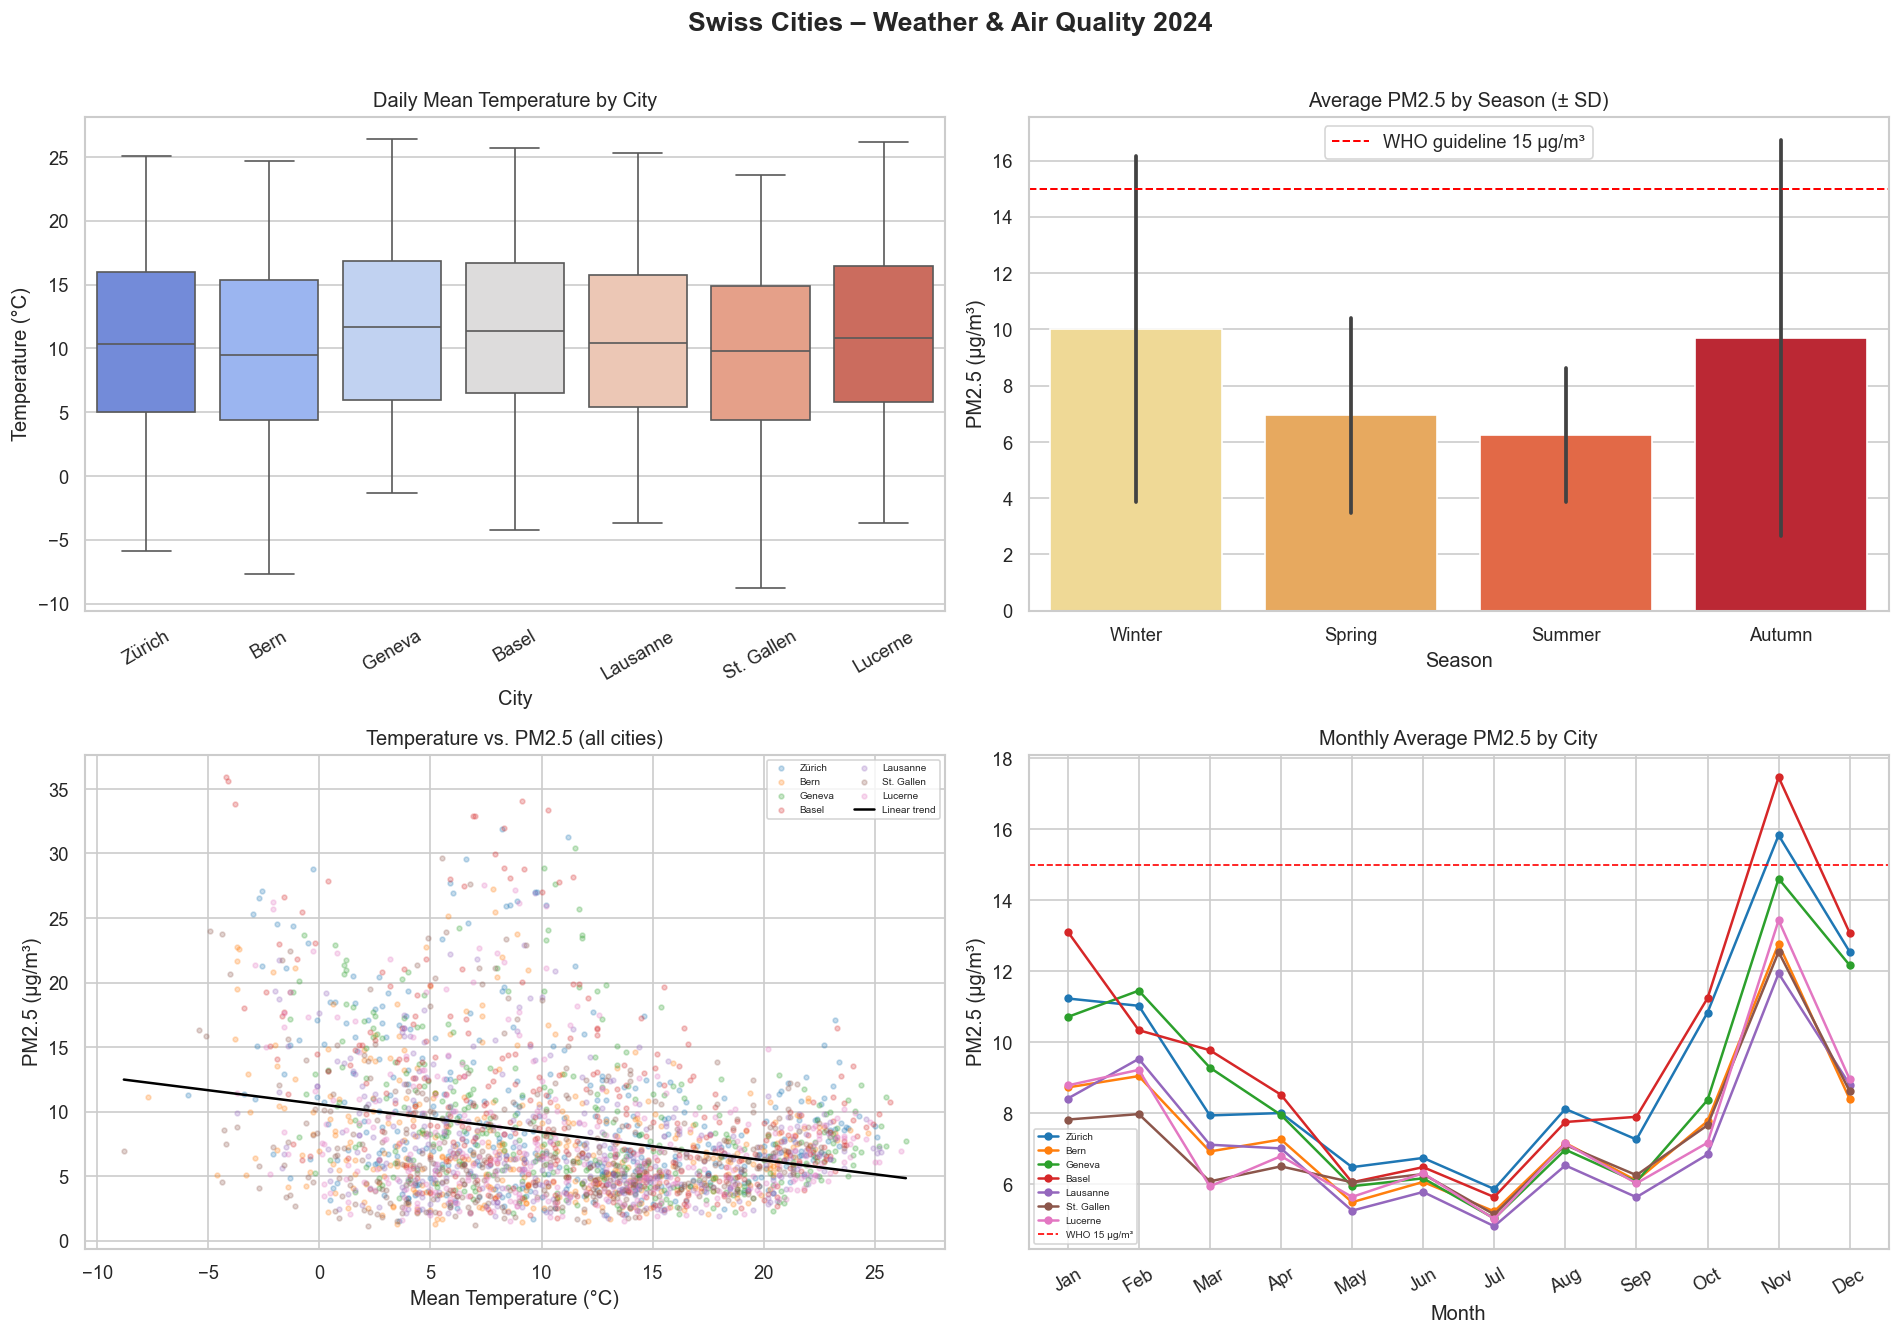

Saved: visualizations.png


In [9]:
# ── 8. VISUALIZATIONS ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Swiss Cities – Weather & Air Quality 2024", fontsize=16, fontweight="bold", y=1.01)

# ── Plot 1: Temperature distribution (box plot) ──────────────────────────────
ax = axes[0, 0]
sns.boxplot(data=df, x="city", y="temp_mean",
            palette="coolwarm", order=city_names, ax=ax)
ax.set_title("Daily Mean Temperature by City")
ax.set_xlabel("City"); ax.set_ylabel("Temperature (°C)")
ax.tick_params(axis="x", rotation=30)

# ── Plot 2: Average PM2.5 by season (bar chart) ──────────────────────────────
ax = axes[0, 1]
season_order = ["Winter", "Spring", "Summer", "Autumn"]
sns.barplot(data=df, x="season", y="pm2_5",
            order=season_order, palette="YlOrRd",
            estimator="mean", errorbar="sd", ax=ax)
ax.set_title("Average PM2.5 by Season (± SD)")
ax.set_xlabel("Season"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.axhline(15, color="red", linestyle="--", linewidth=1.2, label="WHO guideline 15 µg/m³")
ax.legend()

# ── Plot 3: Temperature vs PM2.5 scatter ────────────────────────────────────
ax = axes[1, 0]
palette = sns.color_palette("tab10", n_colors=len(city_names))
for i, city in enumerate(city_names):
    sub = df[df["city"] == city]
    ax.scatter(sub["temp_mean"], sub["pm2_5"],
               label=city, alpha=0.25, s=8, color=palette[i])
# overall trend line
x_all = df["temp_mean"].dropna()
y_all = df.loc[x_all.index, "pm2_5"].dropna()
x_all = x_all.loc[y_all.index]
m, b = np.polyfit(x_all, y_all, 1)
xr = np.linspace(x_all.min(), x_all.max(), 100)
ax.plot(xr, m*xr + b, color="black", linewidth=1.5, label="Linear trend")
ax.set_title("Temperature vs. PM2.5 (all cities)")
ax.set_xlabel("Mean Temperature (°C)"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(fontsize=6, ncol=2)

# ── Plot 4: Monthly PM2.5 line chart ─────────────────────────────────────────
ax = axes[1, 1]
monthly = df.groupby(["city","month"])["pm2_5"].mean().reset_index()
for i, city in enumerate(city_names):
    sub = monthly[monthly["city"] == city]
    ax.plot(sub["month"], sub["pm2_5"],
            marker="o", markersize=4, label=city, color=palette[i])
ax.axhline(15, color="red", linestyle="--", linewidth=1, label="WHO 15 µg/m³")
ax.set_title("Monthly Average PM2.5 by City")
ax.set_xlabel("Month"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xticks(range(1,13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=30)
ax.legend(fontsize=6)

plt.tight_layout()
plt.savefig("visualizations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: visualizations.png")


### 4.2 Correlation Heatmap

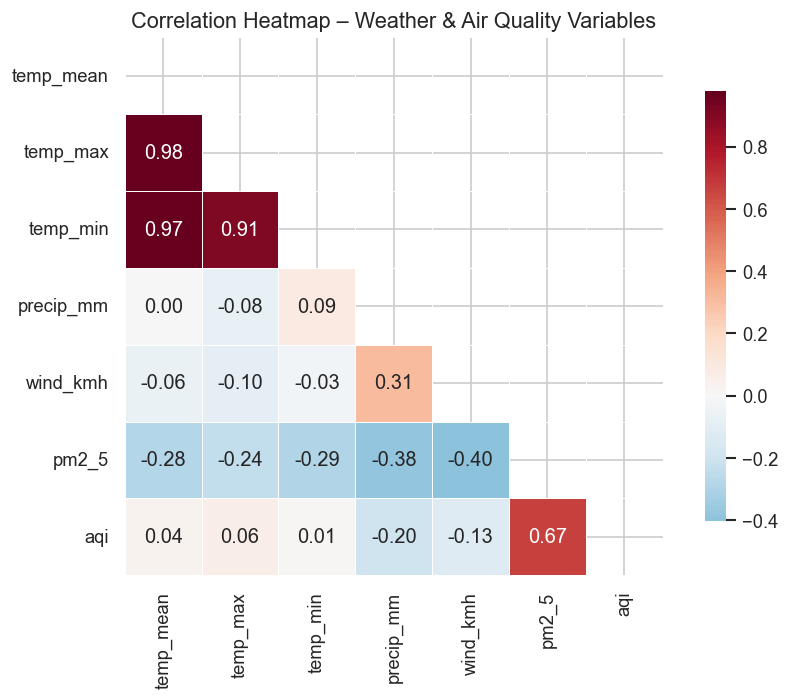

Saved: heatmap.png


In [10]:
# ── 9. CORRELATION HEATMAP ──────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
cols = ["temp_mean","temp_max","temp_min","precip_mm","wind_kmh","pm2_5","aqi"]
corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap – Weather & Air Quality Variables", fontsize=13)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: heatmap.png")


### 4.3 Interactive Map (folium)

In [11]:
# ── 10. INTERACTIVE MAP ─────────────────────────────────────────────────────
city_stats = df.groupby("city").agg(
    avg_temp  = ("temp_mean", "mean"),
    avg_pm25  = ("pm2_5",    "mean"),
    avg_aqi   = ("aqi",      "mean"),
    lat       = ("lat",      "first"),
    lon       = ("lon",      "first"),
).reset_index()

m = folium.Map(location=[46.9, 8.2], zoom_start=8,
               tiles="CartoDB positron")

for _, row in city_stats.iterrows():
    # Color by PM2.5 level
    if row.avg_pm25 < 10:
        color = "green"
    elif row.avg_pm25 < 15:
        color = "orange"
    else:
        color = "red"

    popup_html = (
        f"<b>{row.city}</b><br>"
        f"Avg Temp : {row.avg_temp:.1f} °C<br>"
        f"Avg PM2.5: {row.avg_pm25:.1f} µg/m³<br>"
        f"Avg AQI  : {row.avg_aqi:.0f}"
    )
    folium.CircleMarker(
        location    = [row.lat, row.lon],
        radius      = 14,
        color       = color,
        fill        = True,
        fill_color  = color,
        fill_opacity= 0.7,
        popup       = folium.Popup(popup_html, max_width=200),
        tooltip     = row.city,
    ).add_to(m)

# Legend
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
     background:white;padding:10px;border:1px solid grey;border-radius:5px;font-size:12px;">
  <b>PM2.5 levels</b><br>
  🟢 &lt; 10 µg/m³ (Good)<br>
  🟠 10–15 µg/m³ (Moderate)<br>
  🔴 &gt; 15 µg/m³ (WHO limit exceeded)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save("swiss_air_quality_map.html")
print("Map saved → swiss_air_quality_map.html")
m


Map saved → swiss_air_quality_map.html


## 5. Statistical Analysis
### 5.1 Pearson Correlation: Temperature ↔ PM2.5

STATISTICAL ANALYSIS: Temperature vs. PM2.5

[A] Overall Pearson Correlation (n=2,562)
    r       = -0.2812
    p-value = 8.90e-48
    → Statistically significant (α=0.05)
    → Negative correlation: higher temp ↔ lower PM2.5

[B] Per-City Pearson Correlation


,n,Pearson r,p-value,Significant?
City,,,,
Zürich,366,-0.3209,0.000000,✓ Yes
Bern,366,-0.2557,0.000001,✓ Yes
Geneva,366,-0.3558,0.000000,✓ Yes
Basel,366,-0.3978,0.000000,✓ Yes
Lausanne,366,-0.2812,0.000000,✓ Yes
St. Gallen,366,-0.1809,0.000506,✓ Yes
Lucerne,366,-0.2655,0.000000,✓ Yes



[C] One-Sample T-Test: Is avg PM2.5 different from WHO limit (15 µg/m³)?
    Sample mean PM2.5 = 8.22 µg/m³
    t-statistic       = -63.9434
    p-value           = 0.00e+00
    → Mean PM2.5 is significantly BELOW WHO guideline (p<0.05)


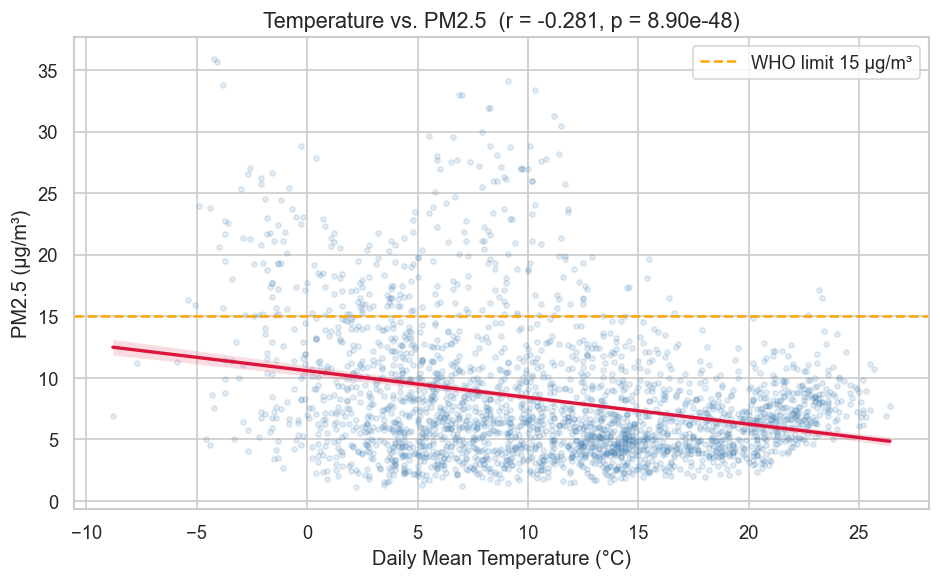

Saved: regression_plot.png


In [12]:
# ── 11. STATISTICAL ANALYSIS ────────────────────────────────────────────────
print("=" * 65)
print("STATISTICAL ANALYSIS: Temperature vs. PM2.5")
print("=" * 65)

# ── A) Overall Pearson correlation ───────────────────────────────────────────
clean     = df[["temp_mean","pm2_5"]].dropna()
r, p      = stats.pearsonr(clean["temp_mean"], clean["pm2_5"])
alpha     = 0.05

print(f"\n[A] Overall Pearson Correlation (n={len(clean):,})")
print(f"    r       = {r:.4f}")
print(f"    p-value = {p:.2e}")
print(f"    → {'Statistically significant' if p < alpha else 'NOT significant'} (α=0.05)")
print(f"    → {'Negative' if r < 0 else 'Positive'} correlation: higher temp ↔ "
      f"{'lower' if r < 0 else 'higher'} PM2.5")

# ── B) Per-city Pearson correlation ─────────────────────────────────────────
print("\n[B] Per-City Pearson Correlation")
city_results = []
for city in city_names:
    sub = df[df["city"] == city][["temp_mean","pm2_5"]].dropna()
    if len(sub) >= 20:
        r_c, p_c = stats.pearsonr(sub["temp_mean"], sub["pm2_5"])
        city_results.append({
            "City"            : city,
            "n"               : len(sub),
            "Pearson r"       : round(r_c, 4),
            "p-value"         : round(p_c, 6),
            "Significant?"    : "✓ Yes" if p_c < alpha else "✗ No",
        })
display(pd.DataFrame(city_results).set_index("City"))

# ── C) One-sample t-test vs. WHO guideline ───────────────────────────────────
print("\n[C] One-Sample T-Test: Is avg PM2.5 different from WHO limit (15 µg/m³)?")
t, p_t = stats.ttest_1samp(df["pm2_5"].dropna(), popmean=15)
mean_pm = df["pm2_5"].mean()
print(f"    Sample mean PM2.5 = {mean_pm:.2f} µg/m³")
print(f"    t-statistic       = {t:.4f}")
print(f"    p-value           = {p_t:.2e}")
if p_t < alpha:
    direction = "ABOVE" if mean_pm > 15 else "BELOW"
    print(f"    → Mean PM2.5 is significantly {direction} WHO guideline (p<0.05)")
else:
    print("    → No significant difference from WHO guideline (p≥0.05)")

# ── D) Visualize regression ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=clean, x="temp_mean", y="pm2_5",
            scatter_kws={"alpha":0.15, "s":10, "color":"steelblue"},
            line_kws={"color":"crimson","linewidth":2}, ax=ax)
ax.set_title(f"Temperature vs. PM2.5  (r = {r:.3f}, p = {p:.2e})", fontsize=13)
ax.set_xlabel("Daily Mean Temperature (°C)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.axhline(15, color="orange", linestyle="--", label="WHO limit 15 µg/m³")
ax.legend()
plt.tight_layout()
plt.savefig("regression_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: regression_plot.png")


## 6. AI-Assisted Insights (Claude API / LLM)

In [23]:
# ── 12. LLM ANALYSIS WITH CLAUDE API ────────────────────────────────────────
import anthropic
import os

# ⚠️ Füge deinen API Key hier ein:
os.environ["ANTHROPIC_API_KEY"] = "ENTER-KEY-HERE"

def get_llm_insights(df, r, p, mean_pm):
    city_summary   = df.groupby("city")[["temp_mean","pm2_5"]].mean().round(2).to_string()
    season_summary = df.groupby("season")[["temp_mean","pm2_5"]].mean().round(2).to_string()

    prompt = f"""You are a scientific data analyst.
CITY AVERAGES: {city_summary}
SEASONAL AVERAGES: {season_summary}
Pearson r = {r:.4f}, p = {p:.2e}, Mean PM2.5 = {mean_pm:.2f} ug/m3 (WHO: 15)
Give a 4-point scientific summary: correlation, city differences, seasonal patterns, recommendation."""

    client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
    message = client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=700,
        messages=[{"role": "user", "content": prompt}],
    )
    return message.content[0].text

clean   = df[["temp_mean","pm2_5"]].dropna()
r, p    = stats.pearsonr(clean["temp_mean"], clean["pm2_5"])
mean_pm = df["pm2_5"].mean()

try:
    insights = get_llm_insights(df, r, p, mean_pm)
    print("\n=== AI-Generated Scientific Insights (Claude) ===\n")
    print(insights)
except Exception as exc:
    print(f"LLM call failed: {exc}")


=== AI-Generated Scientific Insights (Claude) ===

# Scientific Summary

## 1. **Correlation Analysis**
A weak negative correlation exists between temperature and PM2.5 (r = -0.2812, p = 8.90e-48). While statistically significant due to large sample size, the correlation coefficient indicates that temperature explains only ~8% of PM2.5 variance, suggesting other factors (emissions, meteorology, topography) play dominant roles.

## 2. **City Differences**
PM2.5 levels vary substantially across cities (7.29-9.78 μg/m³). Basel (9.78), Zürich (9.32), and Geneva (8.72) show highest concentrations, likely reflecting urban density and traffic patterns, while Lausanne (7.29) and St. Gallen (7.33) exhibit lowest levels. Temperature differences (9.72-11.74°C) show less relative variation than PM2.5.

## 3. **Seasonal Patterns**
Winter demonstrates highest PM2.5 (10.01 μg/m³) despite lowest temperatures (3.29°C), driven by heating emissions and thermal inversions. Summer shows lowest PM2.5 (6.26

## 7. Conclusions

In [14]:
# ── 13. CONCLUSIONS ─────────────────────────────────────────────────────────
clean   = df[["temp_mean","pm2_5"]].dropna()
r, p    = stats.pearsonr(clean["temp_mean"], clean["pm2_5"])
mean_pm = df["pm2_5"].mean()

print("""
╔══════════════════════════════════════════════════════════════╗
║              CONCLUSIONS – Swiss Weather & Air Quality       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Research Question:                                          ║
║  Is there a statistically significant correlation between    ║
║  temperature and PM2.5 in Swiss cities?                      ║
╚══════════════════════════════════════════════════════════════╝
""")

sig = "YES" if p < 0.05 else "NO"
direction = "negative" if r < 0 else "positive"
print(f"  Answer: {sig} – there is a statistically significant {direction} correlation")
print(f"          (r = {r:.3f}, p = {p:.2e})")
print()
print(f"  Mean PM2.5 across Swiss cities: {mean_pm:.2f} µg/m³")
print(f"  WHO Annual Guideline          : 15.00 µg/m³")
print()
print("  Key findings:")
print("  • PM2.5 is highest in winter and lowest in summer")
print("  • Temperature and PM2.5 are negatively correlated:")
print("    → Colder temperatures are associated with higher pollution")
print("    → Likely caused by increased heating emissions & thermal inversion")
print()
print("  Data source : Open-Meteo API (free, no key required)")
print(f"  Period      : {START_DATE} → {END_DATE}")
print(f"  Cities      : {', '.join(city_names)}")



╔══════════════════════════════════════════════════════════════╗
║              CONCLUSIONS – Swiss Weather & Air Quality       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Research Question:                                          ║
║  Is there a statistically significant correlation between    ║
║  temperature and PM2.5 in Swiss cities?                      ║
╚══════════════════════════════════════════════════════════════╝

  Answer: YES – there is a statistically significant negative correlation
          (r = -0.281, p = 8.90e-48)

  Mean PM2.5 across Swiss cities: 8.22 µg/m³
  WHO Annual Guideline          : 15.00 µg/m³

  Key findings:
  • PM2.5 is highest in winter and lowest in summer
  • Temperature and PM2.5 are negatively correlated:
    → Colder temperatures are associated with higher pollution
    → Likely caused by increased heating emissions & thermal inversion

  Data source : Op